In [1]:
import pandas as pd

import sklearn as sk
from sklearn import model_selection
from sklearn import ensemble
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [33]:
def show_all_rows(df):
    with pd.option_context("display.max_rows", None, 
                       "display.max_columns", None,
                       "display.max_colwidth", None):
        display(df)

# ARS a USD
def transformacion_ars_usd(df):
    f=df["currency"]=="ARS"
    df.loc[f,"price"]=df.loc[f,"price"]*78.5
    df.loc[f,"currency"]="USD"
    return df

# 1EROS Filtros
def primeros_filtros(df_ent ,df_ap):
    df_ent = df_ent.loc[(df_ent["price"].notna()) & (df_ent["currency"] == "USD") & \
    (df_ent["l2"] == "Capital Federal") & (df_ent["operation_type"] == 'Venta') & \
    (df_ent["l3"].isin(df_ap["l3"].unique()))&\
    (df_ent["property_type"].isin(["Cochera", "Departamento", "Casa","PH"]))]

    df_ent=df_ent.drop_duplicates()
    return df_ent

def conversion_ph_to_casa(df):
    f=df["property_type"] =="PH"
    df.loc[f,"ph"] =1
    df.loc[~f,"ph"]=0
    df.loc[f,"property_type"] = "Casa"
    return df


# L3 & L4
def extraccion_l4_text(df):
    subgrupos_to_barrios = {
    # Recoleta
    'Barrio Norte': 'Recoleta',

    # Balvanera
    'Once': 'Balvanera',
    'Abasto': 'Balvanera',

    # Palermo
    'Palermo Hollywood': 'Palermo',
    'Palermo Soho': 'Palermo',
    'Palermo Viejo': 'Palermo',
    'Palermo Chico': 'Palermo',
    'Las Cañitas': 'Palermo',

    # Monserrat
    'Congreso': 'Monserrat',

    # Retiro
    'Catalinas': 'Retiro',

    # San Nicolás
    'Tribunales': 'San Nicolás',
    'Centro / Microcentro': 'San Nicolás',

    # Chacarita
    'Distrito Audiovisual': 'Colegiales',

    'Velez Sarsfield' : 'Versalles',

    'Parque Centenario':'Caballito',

}
    barrios_y_subbarrios_variantes = [
        "Agronomía|Agronomia", "Almagro", "Balvanera", "Barracas", "Belgrano", "Boca",
        "Boedo", "Caballito", "Chacarita", "Coghlan|Coglan", "Colegiales",
        "Constitución|Constitucion", "Flores", "Floresta", "Liniers", "Mataderos",
        "Monserrat", "Monte Castro", "Pompeya", "Nuñez|Nunez|Núñez", "Palermo",
        "Parque Avellaneda", "Parque Chacabuco", "Parque Chas",
        "Parque Patricios", "Paternal", "Puerto Madero", "Recoleta", "Retiro",
        "Saavedra", "San Cristobal", "San Nicolás|San Nicolas", "San Telmo",
        "Velez Sarsfield|Vélez Sarsfield|Velez", "Versalles", "Villa Crespo",
        "Villa del Parque", "Villa Devoto|Devoto", "Villa General Mitre|Villa Gral Mitre",
        "Villa Lugano|Lugano", "Villa Luro", "Villa Ortuzar|Villa Ortúzar",
        "Villa Pueyrredón|Villa Pueyrredon", "Villa Real", "Villa Riachuelo",
        "Villa Santa Rita", "Villa Soldati", "Villa Urquiza|Urquiza",

        # Subbarrios / L4 y zonas comunes
        "Palermo Hollywood", "Palermo Soho", "Palermo Viejo", "Palermo Chico",
        "Las Cañitas|Cañitas|Canitas", "Barrio Norte", "Once", "Abasto",
        "Congreso", "Catalinas", "Tribunales",
        "Centro / Microcentro|Microcentro|Centro",
        "Parque Centenario", "Distrito Audiovisual"]

    #Extraigo de title y describe
    for barrio in barrios_y_subbarrios_variantes:
        # f_desc=(df["description"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
        f_title= (df["title"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
        # df.loc[f_desc,"l4_descr"] = barrio.split(sep='|')[0]
        df.loc[f_title,"l4_title"] = barrio.split(sep='|')[0]

        # Lleno los nan con title
    f_l4_nan_1 = (df["l4"].isna()) & (df["l4_title"].notna())
    df.loc[f_l4_nan_1 , "l4"] = df.loc[f_l4_nan_1 , "l4_title"]

    
        # Lleno los nan de l3 con l4 y viceversa
    f_l3_nan = (df["l3"].isna())&(df["l4"].notna())
    df.loc[f_l3_nan,"l3"]= df.loc[f_l3_nan,"l4"]

    f_l4_nan = (df["l4"].isna())&(df["l3"].notna())
    df.loc[f_l4_nan,"l4"]= df.loc[f_l4_nan,"l3"]
    print(f"nan en l3: {df['l3'].isna().sum()}")
    print(f"nan en l4: {df['l4'].isna().sum()}")


        # Lleno los nan que faltan de l3 y l4 con describe (a esta altura ya tenemos la misma cantidad de nan en l3 y l4)
    for barrio in barrios_y_subbarrios_variantes:
        f_nan = df["l3"].isna()
        f_desc=(df.loc[f_nan,"description"].str.lower().str.contains(barrio.lower(),regex=True,na=False))
        df.loc[f_nan & f_desc,"l4_descr"] = barrio.split(sep='|')[0]
    
    f_l4_nan_2 = (df["l4"].isna()) & (df["l4_title"].isna()) & (df["l4_descr"].notna())
    df.loc[f_l4_nan_2 , "l4"] = df.loc[f_l4_nan_2 , "l4_descr"]
    df.loc[f_l4_nan_2 , "l3"] = df.loc[f_l4_nan_2 , "l4_descr"]

    print(f"nan en l3 final: {df['l3'].isna().sum()}")
    print(f"nan en l4 final: {df['l4'].isna().sum()}")
        # Corrijo barrios y subbarrios
    for subbarrio,barrio in subgrupos_to_barrios.items():
        f=df["l4"] == subbarrio
        df.loc[f,"l3"] = barrio

        f=df["l3"] == subbarrio
        df.loc[f,"l4"] = subbarrio
        df.loc[f,"l3"] = barrio

    return df

def eliminacion_nan_l3_l4(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna() 
    f_nan=df["l3"].notna()
    df = df.loc[f_nan | f_ap]
    return df


# Lat & Lon
def tratamiento_outlayers_lat_lon(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna()
    
    aux=df["lat"]
    df["lat"]=df["lon"]
    df["lon"]=aux

    f=df["lon"]>-60
    max_lat=df.loc[f&f_ap,"lat"].max()
    min_lat=df.loc[f&f_ap,"lat"].min()
    max_lon=df.loc[f&f_ap,"lon"].max()
    min_lon=df.loc[f&f_ap,"lon"].min()
    print(max_lat,min_lat,max_lon,min_lon)

    f_in=(df["lat"]<=max_lat) & (df["lat"]>=min_lat)&(df["lon"]<= max_lon)&(df["lon"]>= min_lon)
    f_out=~f_in
    df.loc[f_out,["lat","lon"]]=np.nan

    return df

def imputacion_nan_lat_lon(df):
    coordenadas_medias_l4=df.groupby("l3")[["lat","lon"]].mean()
    # print(coordenadas_medias_l4.loc["Palermo"])

    barrios=df["l3"].dropna().unique()
    for l in barrios :
        f_l=df["l3"] == l
        f_nan = df["lat"].isna()
        df.loc[f_l &f_nan ,"lat"] = coordenadas_medias_l4.loc[l]["lat"]
        df.loc[f_l &f_nan ,"lon"] = coordenadas_medias_l4.loc[l]["lon"]
    return df
    
def col_dataset(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna()
    df["dataset"]=np.zeros(df.shape[0])
    df.loc[f_ent,"dataset"]=1
    return df

def eliminacion_nan_lat_lon(df):
    f_ap=df["price"].isna()
    f_ent=df["price"].notna()
    f=((df["lat"].notna()) & (df["lon"].notna()))
    df=df.loc[f | f_ap]
    return df

# rooms, bedrooms , bathrooms
def extraction_rooms_text(df):
    rooms = {k:f"{k} amb" for k in range(1,int(df["rooms"].max()+1))}
    for k,v in rooms.items():
        if k == 1 :
            f1=(df["title"].str.lower().str.contains(v,na=False)) | (df["title"].str.lower().str.contains("monoamb",na=False))
            df.loc[f1,"rooms_title"]=k
        else:
            fi=df["title"].str.lower().str.contains(v,na=False)
            df.loc[fi,"rooms_title"]=k

    rooms = {k:f"{k} amb" for k in range(1,int(df["rooms"].max()+1))}

    for k,v in rooms.items():
        if k == 1 :
            f1=(df["description"].str.lower().str.contains(v)) | (df["description"].str.lower().str.contains("monoamb"))
            df.loc[f1,"rooms_description"]=k
        else:
            fi=df["description"].str.lower().str.contains(v,na=False)
            df.loc[fi,"rooms_description"]=k
    
    return df

def categorize_rooms(row):
  vals=[row["rooms"] , row["rooms_title"],row["rooms_description"]]
  not_nulls = [v for v in vals if pd.notna(v)]

  if len(not_nulls)==0:
    return "Todas NaN"
  elif len(not_nulls)==1:
    return "Solo 1 valor"
  elif len(not_nulls)==2:
    if not_nulls[0]==not_nulls[1]:
      return "2 iguales, 1 NaN"
    else:
      return "2 distintos, 1 NaN"
  else:
    vals_unique=set(not_nulls)
    if len(vals_unique)==1:
      return "3 iguales"
    elif  len(vals_unique)==2:
      return "2 iguales, 1 distinto"
    else:
      return "3 distintos"

def rooms_def(row):
  vals=[row["rooms"] , row["rooms_title"],row["rooms_description"]]
  not_nulls = [v for v in vals if pd.notna(v)]
  if ((row["categorize_rooms"] == "3 iguales") | (row["categorize_rooms"] == "3 distintos")) :
    return row["rooms_title"]
  elif (row["categorize_rooms"] == "2 iguales, 1 distinto")|(row["categorize_rooms"] == "2 iguales, 1 NaN"):
    if row["rooms"]==row["rooms_description"]:
      return row["rooms"]
    else:
      return row["rooms_title"]
  elif (row["categorize_rooms"] == "2 distintos, 1 NaN"):
    if pd.isna(row["rooms_title"]):
      return row["rooms"]
    else:
      return row["rooms_title"]
  elif (row["categorize_rooms"] == "Solo 1 valor"):
    return not_nulls[0]
  else:
    return np.nan

def tratamiento_outlayers_ambientes(df):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   f_dpto=df["property_type"] =="Departamento"
   f_casa=df["property_type"] =="Casa"
   f_coch=df["property_type"] == "Cochera"
   
   # Rooms
   max_rooms_dpto = df.loc[f_ap & f_dpto,"rooms_def"].max()
   print(f"Max rooms dptos: {max_rooms_dpto}")
   f_max_dpto=df["rooms_def"]> max_rooms_dpto
   print(f"Pasando a nan {df.loc[f_dpto & f_max_dpto].shape[0]} rooms de deptos")
   df.loc[f_dpto & f_max_dpto,"rooms_def"] = np.nan

   max_rooms_casa = df.loc[f_ap & f_casa,"rooms_def"].max()
   print(f"Max rooms casas: {max_rooms_casa}")
   f_max_casa=df["rooms_def"]> max_rooms_casa
   print(f"Pasando a nan {df.loc[f_casa & f_max_casa].shape[0]} rooms de casas")
   df.loc[f_casa & f_max_casa,"rooms_def"] = np.nan

   # Bedrooms
   max_bedrooms_dpto = df.loc[f_ap & f_dpto,"bedrooms"].max()
   print(f"Max bedrooms dptos: {max_bedrooms_dpto}")
   f_max_dpto=df["bedrooms"]> max_bedrooms_dpto
   print(f"Pasando a nan {df.loc[f_dpto & f_max_dpto].shape[0]} bedrooms de deptos")
   df.loc[f_dpto & f_max_dpto,"bedrooms"] = np.nan

   max_bedrooms_casa = df.loc[f_ap & f_casa,"bedrooms"].max()
   print(f"Max bedrooms casas: {max_bedrooms_casa}")
   f_max_casa=df["bedrooms"]> max_bedrooms_casa
   print(f"Pasando a nan {df.loc[f_casa & f_max_casa].shape[0]} bedrooms de casas")
   df.loc[f_casa & f_max_casa,"bedrooms"] = np.nan

   # Bathrooms
   max_bathrooms_dpto = df.loc[f_ap & f_dpto,"bathrooms"].max()
   print(f"Max bathrooms dptos: {max_bathrooms_dpto}")
   f_max_dpto=df["bathrooms"]> max_bathrooms_dpto
   print(f"Pasando a nan {df.loc[f_dpto & f_max_dpto].shape[0]} bathrooms de deptos")
   df.loc[f_dpto & f_max_dpto,"bathrooms"] = np.nan

   max_bathrooms_casa = df.loc[f_ap & f_casa,"bathrooms"].max()
   print(f"Max bathrooms casas: {max_bathrooms_casa}")
   f_max_casa=df["bathrooms"]> max_bathrooms_casa
   print(f"Pasando a nan {df.loc[f_casa & f_max_casa].shape[0]} bathrooms de casas")
   df.loc[f_casa & f_max_casa,"bathrooms"] = np.nan
   return df

def imputacion_espacios(row):


    if row["property_type"] == "Cochera":
        rooms_def =0
        bedrooms = 0
        bathrooms = 0
        
    else:
      
        # Cuando rooms_def no es nan : Aca corrijo y recupero todos los que son nan en bathrooms y bedrooms pero no en rooms_def
        if not pd.isna(row["rooms_def"]):
            rooms_def=row["rooms_def"]
            
            # Caso de rooms ==1 o 2. Ponemos baños y bedrooms 1. Este es para todos
            if rooms_def <= 2:
                bedrooms = 1
                bathrooms = 1

            # Caso de rooms >2. bedrooms restamos 1 y bathrooms 2 
            elif rooms_def >2:
                bedrooms= rooms_def - 1

                if (row["bathrooms"] > rooms_def) | (pd.isna(row["bathrooms"])) |(row["bathrooms"]==0):
                    bathrooms = rooms_def - 2
                else:
                    bathrooms = row["bathrooms"]
        else:
            if (pd.notna(row["bedrooms"])) & ((row["bathrooms"]> row["bedrooms"]) |(pd.isna(row["bathrooms"]))) :
                bedrooms = row["bedrooms"]
                rooms_def = bedrooms + 1
                bathrooms = bedrooms
            elif (pd.notna(row["bedrooms"])) & (row["bathrooms"]<= row["bedrooms"]):
                bedrooms = row["bedrooms"]
                rooms_def = bedrooms + 1
                bathrooms = row["bathrooms"]

            elif (pd.isna(row["bedrooms"])) & (pd.notna(row["bathrooms"]) ):
                
                bathrooms=row["bathrooms"]
                bedrooms = bathrooms+1
                rooms_def = bathrooms +2
            
            elif (pd.isna(row["bedrooms"])) & (pd.isna(row["bathrooms"])) :
                bathrooms=np.nan
                bedrooms = np.nan
                rooms_def = np.nan

            else:
                print(f"ESTE CASO NO LO CONTEMPLE. Es el indice {row.name}")

                bathrooms=row["bathrooms"]
                bedrooms = row["bedrooms"]
                rooms_def = row["rooms_def"]

    return pd.Series({"rooms_def": rooms_def,"bedrooms": bedrooms,"bathrooms": bathrooms})

# Surface_covered & Surface_total
def rotacion_cov_tot(df):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   f=df["surface_covered"] > df["surface_total"]
   print(f"cantidad cov>tot en ent:{df.loc[f & f_ent].shape[0]}")
   print(f"cantidad cov>tot en ap:{df.loc[f & f_ap].shape[0]}")

   temp = df.loc[f, "surface_covered"].copy()
   df.loc[f, "surface_covered"] = df.loc[f, "surface_total"]
   df.loc[f, "surface_total"] = temp

   f=df["surface_covered"] > df["surface_total"]
   print(f"cantidad cov>tot en ent después de rotacion:{df.loc[f & f_ent].shape[0]}")
   print(f"cantidad cov>tot en ap después de rotacion:{df.loc[f & f_ap].shape[0]}")
   return df


def outliers_surface_ap(df,surface):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   f_dpto=df["property_type"] =="Departamento"
   f_casa=df["property_type"] =="Casa"
   f_coch=df["property_type"] == "Cochera"


   f_lsup_dpto=df[surface] > 1000 # Me quedo con el max de ap en covered :) --- corrijo en total
   print(f"valores max de deptos en ap de {surface} a pasar a nan {df.loc[f_ap & f_dpto & f_lsup_dpto,surface].shape[0]}")
   df.loc[f_ap & f_dpto & f_lsup_dpto,surface]= np.nan

   f_linf_dpto = df[surface] < 14 # Corrijo el minimo
   print(f"valores min de deptos en ap de {surface} a pasar a nan {df.loc[f_ap & f_dpto & f_linf_dpto,surface].shape[0]}")
   df.loc[f_ap & f_dpto & f_linf_dpto,surface] = np.nan

   print(f"Max y min de deptos en ap : {df.loc[f_ap&f_dpto,surface].agg(['max','min'])}")

        # Casa 
   f_lsup_casa=df[surface] > 10000 # Me quedo con el max de ap :)
   print(f"valores max de casas en ap de {surface} a pasar a nan {df.loc[f_ap & f_casa & f_lsup_casa,surface].shape[0]}")
   df.loc[f_ap & f_casa & f_lsup_casa,surface]= np.nan

   f_linf_casa=df[surface] < 20 # Corrijo el minimo
   print(f"valores min de casas en ap de {surface} a pasar a nan {df.loc[f_ap & f_casa & f_linf_casa,surface].shape[0]}")
   df.loc[f_ap & f_casa & f_linf_casa,surface]= np.nan
   print(f"Max y min de casas en ap : {df.loc[f_ap&f_casa,surface].agg(['max','min'])}")

        # Cochera
   f_lsup_coch=df[surface] > 10000 # Me quedo con el max de ap :)
   print(f"valores max de cocheras en ap de {surface} a pasar a nan {df.loc[f_ap & f_coch & f_lsup_coch,surface].shape[0]}")
   df.loc[f_ap & f_coch & f_lsup_coch,surface]= np.nan

   f_linf_coch=df[surface] < 8 # Corrijo el minimo
   print(f"valores min de cocheras en ap de {surface} a pasar a nan {df.loc[f_ap & f_coch & f_linf_coch,surface].shape[0]}")
   df.loc[f_ap & f_coch & f_linf_coch,surface]= np.nan
   print(f"Max y min de cocheras en ap : {df.loc[f_ap&f_coch,surface].agg(['max','min'])}")

   return df
def imputacion_covered_con_total_viceversa(df):
   f_cov_na = (df["surface_covered"].isna()) & (df["surface_total"].notna())
   f_tot_na= (df["surface_total"].isna()) & (df["surface_covered"].notna())
   print(f"nan en covered antes : {df['surface_covered'].isna().sum()}")
   print(f"nan en total antes : {df['surface_total'].isna().sum()}")

   df.loc[f_cov_na,'surface_covered'] = df.loc[f_cov_na,'surface_total']
   df.loc[f_tot_na,'surface_total'] = df.loc[f_tot_na,'surface_covered']
   print(f"nan en covered despues : {df['surface_covered'].isna().sum()}")
   print(f"nan en total despues : {df['surface_total'].isna().sum()}")
   return df

def outliers_surface_ent(df):
   
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   
   for ppt in ["Departamento","Casa","Cochera"]:
    print("-----------------------------------------------------")
    print(ppt)
    f_ppt=df["property_type"]==ppt
    min_cov = df.loc[f_ppt & f_ap ,"surface_covered"].min()
    max_cov = df.loc[f_ppt & f_ap ,"surface_covered"].max()
    min_tot = df.loc[f_ppt & f_ap ,"surface_total"].min()
    max_tot = df.loc[f_ppt & f_ap ,"surface_total"].max()

    print(f"min cov = {min_cov}")
    print(f"max cov = {max_cov}")
    print(f"min tot = {min_tot}")
    print(f"max tot = {max_tot}")

    f_total_out = (df["surface_total"]> max_tot) | (df["surface_total"]< min_tot)
    f_cov_out = (df["surface_covered"]> max_cov) | (df["surface_covered"]< min_cov)
    

    f_subset_total_out = f_ppt & f_total_out & f_ent 
    print(f"datos de surface_total a nan: {df.loc[f_subset_total_out , 'surface_total'].shape[0]}")
    df.loc[f_subset_total_out , "surface_total"] = np.nan

    f_subset_cov_out = f_ppt & f_cov_out & f_ent 
    print(f"datos de surface_covered a nan: {df.loc[f_subset_cov_out , 'surface_covered'].shape[0]}")
    df.loc[f_subset_cov_out , "surface_covered"] = np.nan
   return df


def outliers_ratio_cov_total(df):
   f_ap=df["price"].isna()
   f_ent=df["price"].notna()
   df["cov_total"] = df["surface_covered"] / df["surface_total"] * 100
   for ppt in ["Departamento","Casa","Cochera"]:
      print(ppt)
      f_ppt=df["property_type"] == ppt
      if ppt =="Departamento":
        min_cov_total= df.loc[f_ap & f_ppt ,"cov_total"].min()
      elif ppt =="Casa":
         min_cov_total=30
      else:
         min_cov_total=70
         
      print(f"min : {min_cov_total}")
      
      f_lim_inf = df["cov_total"] < min_cov_total

      f_out = f_ppt & f_lim_inf
      print(f"Cantidad de valores pasados a nan: {df.loc[f_out ,['surface_covered' , 'surface_total']].shape[0]}")

      df.loc[f_out ,["surface_covered" , "surface_total"]] = np.nan
   
   df["cov_total"] = df["surface_covered"] / df["surface_total"] * 100

   return df


# Price_m2
def calculo_price_m2_real(df):
   df["price_m2_real"]=df["price"]/(df["surface_covered"]+0.001)
   return df
def outlaiers_price_m2_bruto(df):
   lim_inf=500
   lim_sup=10000
   f_lim_inf = df["price_m2_real"] <lim_inf
   f_lim_sup = df["price_m2_real"] > lim_sup
   f_out =  f_lim_inf | f_lim_sup
   f_in = ~f_out
   print(f"shape antes de eliminar primeros outlaiers {df.shape}")
   df=df.loc[f_in]
   print(f"shape despues de eliminar primeros outlaiers {df.shape}")

   return df

def calculo_price_m2_std(df):

    df["original_index"] = df.index
    df["price_m2"] = df["price"] / (df["surface_total"] + 0.001)
    gb = df.groupby(by=["property_type", "l3"])["price_m2"].mean().reset_index()
    df = df[df.columns.drop("price_m2")].merge(gb, on=["property_type", "l3"], how="left")
    df = df.set_index("original_index")
    df.index.name = "id"
    df["price_m2_x_surface_total"] = df["price_m2"] * df["surface_total"]
    return df

def outliers_price_m2_error(df):
    df["error"] = df["price_m2_real"] - df["price_m2"]
    print(f"df shape antes:{df.shape}")
    f_out=np.abs(df["error"])> 1000
    print(f"Cantidad de registros a eliminar: {df.loc[f_out].shape}")
    df=df.loc[~f_out]
    print(f"df shape despues:{df.shape}")
    return df

def outliers_prices_zonap(df):

   
    umbrales_por_l3 = {
    'Agronomía': {'min': 900, 'max': 3800},
        'Almagro': {'min': 900, 'max': 3800},
        'Balvanera': {'min': 700, 'max': 3600},
        'Barracas': {'min': 900, 'max': 3800},
        'Barrio Norte': {'min': 1700, 'max': 4500},
        'Belgrano': {'min': 1000, 'max': 5000},
        'Boedo': {'min': 800, 'max': 3700},
        'Boca': {'min': 500, 'max': 3100},
        'Caballito': {'min': 1000, 'max': 4100},
        'Chacarita': {'min': 1000, 'max': 3800},
        'Coghlan': {'min': 1000, 'max': 4100},
        'Colegiales': {'min': 1200, 'max': 4500},
        'Constitución': {'min': 400, 'max': 3400},
        'Flores': {'min': 700, 'max': 3800},
        'Floresta': {'min': 500, 'max': 3500},
        'Liniers': {'min': 700, 'max': 3800},
        'Mataderos': {'min': 600, 'max': 3500},
        'Monserrat': {'min': 700, 'max': 3700},
        'Monte Castro': {'min': 900, 'max': 3700},
        'Nuñez': {'min': 1000, 'max': 5000},
        'Palermo': {'min': 700, 'max': 8000},
        'Parque Avellaneda': {'min': 500, 'max': 3300},
        'Parque Chacabuco': {'min': 800, 'max': 3700},
        'Parque Chas': {'min': 1000, 'max': 3700},
        'Parque Patricios': {'min': 500, 'max': 3700},
        'Paternal': {'min': 700, 'max': 3700},
        'Pompeya': {'min': 500, 'max': 3000},
        'Puerto Madero': {'min': 1500, 'max': 8300}, 
        'Recoleta': {'min': 1000, 'max': 5000},
        'Retiro': {'min': 1000, 'max': 4500},
        'Saavedra': {'min': 1000, 'max': 3900},
        'San Cristobal': {'min': 600, 'max': 3400},
        'San Nicolás': {'min': 800, 'max': 3500},
        'San Telmo': {'min': 900, 'max': 4000},
        'Versalles': {'min': 700, 'max': 3600},
        'Velez Sarsfield': {'min': 700, 'max': 3600},
        'Villa Crespo': {'min': 1000, 'max': 4000},
        'Villa del Parque': {'min': 1000, 'max': 3700},
        'Villa Devoto': {'min': 1000, 'max': 3900},
        'Villa General Mitre': {'min': 700, 'max': 3600}, 
        'Villa Lugano': {'min': 400, 'max': 2800},
        'Villa Luro': {'min': 800, 'max': 3800},
        'Villa Ortuzar': {'min': 1000, 'max': 3800},
        'Villa Pueyrredón': {'min': 1000, 'max': 3700},
        'Villa Real': {'min': 700, 'max': 3600},
        'Villa Riachuelo': {'min': 400, 'max': 3100},
        'Villa Santa Rita': {'min': 700, 'max': 3800},
        'Villa Soldati': {'min': 400, 'max': 3000},
        'Villa Urquiza': {'min': 1000, 'max': 4200},
    }
    barrios = df["l3"].value_counts().index
    index_out=[]
    for l in barrios :
       print(l)
       f_l = df["l3"] == l
       f_out = (df["price_m2_real"] <umbrales_por_l3[l]["min"]) | (df["price_m2_real"] >umbrales_por_l3[l]["max"])
       print(f"vamos a eliminar : {df.loc[f_l & f_out].shape[0]}")
       index_out=index_out + list(df.loc[f_l & f_out].index)
    return index_out


    # ROOMS vs SURFACE_COVERED
def imputacion_rooms_surface(df):
    print(f"nan surface_covered antes : {df['surface_covered'].isna().sum()}")
    gb_pt_rooms = df.groupby(["property_type","rooms_rec"])["surface_covered"].mean()
    for pt in ["Departamento","Casa"]:
        print("---------------------------------------------------------------------------------")
        print(pt)
        f_pt=df["property_type"]==pt
        
        rooms=df["rooms_rec"].dropna().unique()
        for r in rooms:
            print("***    ***    ***   ***   ***   ***   ***")
            print(r)
            f_r=df["rooms_rec"] == r
            f_cov_nan=df["surface_covered"].isna()
            if (pt,r) in gb_pt_rooms.index:
                print(f"El valor medio de cada room es : {gb_pt_rooms[(pt,int(r))]}")
                df.loc[f_pt & f_r & f_cov_nan , "surface_covered"] = gb_pt_rooms[(pt,int(r))] * r
    print(f"nan surface_covered despues : {df['surface_covered'].isna().sum()}")
    return df


## 0. Lectura de datos

In [3]:
df_ent=pd.read_csv("datos/entrenamiento.csv",index_col="id")
df_ap=pd.read_csv("datos/a_predecir.csv",index_col="id")

## 1. Entender los datos (AID)

## 2. Limpiar y transformar los datos (MD)

In [4]:
df_ent=transformacion_ars_usd(df_ent)

In [5]:
df_ent=primeros_filtros(df_ent ,df_ap)
df_ent.shape

(113803, 24)

In [6]:
df=pd.concat([df_ent,df_ap],axis=0)

In [7]:
df=conversion_ph_to_casa(df)

In [8]:
# Filtros ap y ent
f_ap=df["price"].isna()
f_ent=df["price"].notna()
print(df.loc[f_ent].shape)
print(df.loc[f_ap].shape)



(113803, 25)
(7012, 25)


-------------
# L3 y L4

In [9]:
df=extraccion_l4_text(df)

nan en l3: 6298
nan en l4: 6298
nan en l3 final: 5184
nan en l4 final: 5184


In [10]:
print(df.shape)
df=eliminacion_nan_l3_l4(df)
print(df.shape)

(120815, 27)
(115634, 27)


In [11]:
df_ent["l3"].unique()

array(['Colegiales', 'Boedo', 'Almagro', 'San Telmo', 'Barrio Norte',
       'Villa Devoto', 'Palermo', 'Monserrat', 'Caballito', 'Balvanera',
       'Villa Ortuzar', 'Villa Urquiza', nan, 'Villa Crespo', 'Once',
       'Saavedra', 'Recoleta', 'Villa General Mitre', 'Villa del Parque',
       'Belgrano', 'Mataderos', 'Floresta', 'Coghlan', 'Flores',
       'Velez Sarsfield', 'Parque Chacabuco', 'Nuñez', 'Constitución',
       'Las Cañitas', 'Puerto Madero', 'Paternal', 'Congreso',
       'Parque Centenario', 'Parque Patricios', 'Pompeya', 'Villa Lugano',
       'San Cristobal', 'Villa Real', 'San Nicolás', 'Boca', 'Versalles',
       'Villa Luro', 'Retiro', 'Chacarita', 'Barracas', 'Monte Castro',
       'Villa Pueyrredón', 'Parque Avellaneda', 'Liniers', 'Abasto',
       'Tribunales', 'Centro / Microcentro', 'Villa Santa Rita',
       'Agronomía', 'Parque Chas'], dtype=object)

In [12]:
df["l3"].unique()

array(['Colegiales', 'Boedo', 'Almagro', 'San Telmo', 'Recoleta',
       'Villa Devoto', 'Palermo', 'Monserrat', 'Caballito', 'Balvanera',
       'Villa Ortuzar', 'Villa Urquiza', 'Villa Crespo', 'Saavedra',
       'Villa General Mitre', 'Villa del Parque', 'Belgrano', 'Mataderos',
       'Floresta', 'Coghlan', 'Flores', 'Versalles', 'Parque Chacabuco',
       'Nuñez', 'Constitución', 'San Nicolás', 'Puerto Madero',
       'Paternal', 'Parque Patricios', 'Pompeya', 'Villa Lugano',
       'San Cristobal', 'Villa Real', 'Boca', 'Villa Luro', 'Retiro',
       'Chacarita', 'Barracas', 'Monte Castro', 'Villa Pueyrredón',
       'Parque Avellaneda', 'Liniers', 'Villa Santa Rita', 'Agronomía',
       'Parque Chas', nan], dtype=object)

------------
# LAT LON

In [13]:
df=tratamiento_outlayers_lat_lon(df)

-34.5360918 -34.69185638 -58.3586777 -58.5300630656


In [14]:
df=imputacion_nan_lat_lon(df)

In [15]:
df=col_dataset(df)

In [16]:
df.shape

(115634, 28)

In [17]:
df=eliminacion_nan_lat_lon(df)
df.shape

(115634, 28)

# ROOMS, BATHROOMS, BEDROOMS

In [18]:
print(df.shape)
df=extraction_rooms_text(df)
df["categorize_rooms"]=df.apply(categorize_rooms,axis=1)
df["rooms_def"]=df.apply(rooms_def,axis=1)
print(df.shape)

(115634, 28)
(115634, 32)


In [19]:
df=tratamiento_outlayers_ambientes(df)

Max rooms dptos: 9.0
Pasando a nan 76 rooms de deptos
Max rooms casas: 16.0
Pasando a nan 21 rooms de casas
Max bedrooms dptos: 11.0
Pasando a nan 9 bedrooms de deptos
Max bedrooms casas: 12.0
Pasando a nan 24 bedrooms de casas
Max bathrooms dptos: 6.0
Pasando a nan 30 bathrooms de deptos
Max bathrooms casas: 8.0
Pasando a nan 11 bathrooms de casas


In [20]:
print(f"nan de rooms, bedrooms y bathrooms {df['rooms_def'].isna().sum() , df['bedrooms'].isna().sum() ,df['bathrooms'].isna().sum() }")
df[["rooms_rec","bedrooms_rec","bathrooms_rec"]]=df.apply(imputacion_espacios,axis=1)
print(f"nan de rooms, bedrooms y bathrooms {df['rooms_rec'].isna().sum() , df['bedrooms_rec'].isna().sum() ,df['bathrooms_rec'].isna().sum() }")


nan de rooms, bedrooms y bathrooms (np.int64(4321), np.int64(36062), np.int64(8329))
nan de rooms, bedrooms y bathrooms (np.int64(432), np.int64(432), np.int64(432))


<Axes: xlabel='bathrooms_rec', ylabel='dataset'>

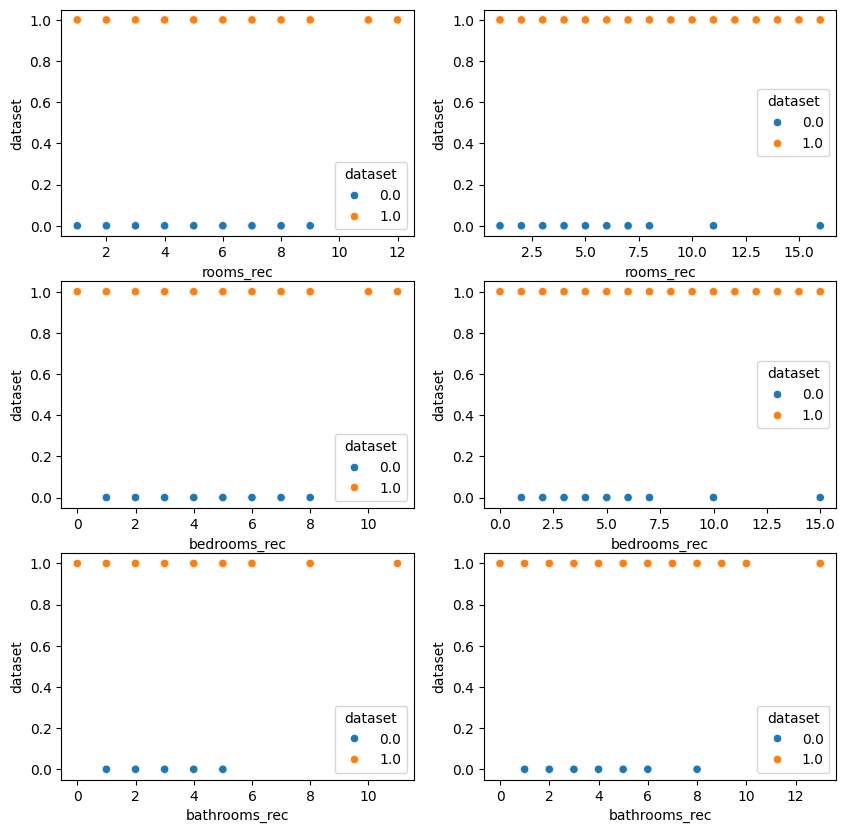

In [21]:
fig , axes = plt.subplots(3,2,figsize = (10,10))
f_dpto=df["property_type"]=="Departamento"
f_casa=df["property_type"]=="Casa"
sns.scatterplot(data=df.loc[ f_dpto] , x="rooms_rec",y="dataset" ,hue="dataset",ax=axes[0,0])
sns.scatterplot(data=df.loc[ f_casa] , x="rooms_rec",y="dataset" ,hue="dataset",ax=axes[0,1])

sns.scatterplot(data=df.loc[ f_dpto] , x="bedrooms_rec",y="dataset" ,hue="dataset",ax=axes[1,0])
sns.scatterplot(data=df.loc[ f_casa] , x="bedrooms_rec",y="dataset" ,hue="dataset",ax=axes[1,1])

sns.scatterplot(data=df.loc[ f_dpto] , x="bathrooms_rec",y="dataset" ,hue="dataset",ax=axes[2,0])
sns.scatterplot(data=df.loc[ f_casa] , x="bathrooms_rec",y="dataset" ,hue="dataset",ax=axes[2,1])

--------

# surface_total vs surface_covered

In [22]:
# Primero damos vuelta los cov>tot
df=rotacion_cov_tot(df)

cantidad cov>tot en ent:829
cantidad cov>tot en ap:27
cantidad cov>tot en ent después de rotacion:0
cantidad cov>tot en ap después de rotacion:0


In [23]:
# Segundo, pasamos outlayers de cada uno a nan
df=outliers_surface_ap(df,"surface_covered")
print('')
print("-------------")
print('')
df=outliers_surface_ap(df,"surface_total")


valores max de deptos en ap de surface_covered a pasar a nan 0
valores min de deptos en ap de surface_covered a pasar a nan 6
Max y min de deptos en ap : max    439.0
min     14.0
Name: surface_covered, dtype: float64
valores max de casas en ap de surface_covered a pasar a nan 0
valores min de casas en ap de surface_covered a pasar a nan 0
Max y min de casas en ap : max    1115.0
min      30.0
Name: surface_covered, dtype: float64
valores max de cocheras en ap de surface_covered a pasar a nan 0
valores min de cocheras en ap de surface_covered a pasar a nan 1
Max y min de cocheras en ap : max    140.0
min      8.0
Name: surface_covered, dtype: float64

-------------

valores max de deptos en ap de surface_total a pasar a nan 1
valores min de deptos en ap de surface_total a pasar a nan 2
Max y min de deptos en ap : max    605.0
min     14.0
Name: surface_total, dtype: float64
valores max de casas en ap de surface_total a pasar a nan 0
valores min de casas en ap de surface_total a pasar a

In [24]:
# Tercero, damos vuelta covered con total
df=imputacion_covered_con_total_viceversa(df)

nan en covered antes : 24174
nan en total antes : 25403
nan en covered despues : 21498
nan en total despues : 21498


In [25]:
# Cuarto, volvemos nan los outlayers de ent con los limites de ap
df=outliers_surface_ent(df)

-----------------------------------------------------
Departamento
min cov = 14.0
max cov = 439.0
min tot = 14.0
max tot = 605.0
datos de surface_total a nan: 226
datos de surface_covered a nan: 286
-----------------------------------------------------
Casa
min cov = 30.0
max cov = 1115.0
min tot = 32.0
max tot = 1515.0
datos de surface_total a nan: 129
datos de surface_covered a nan: 143
-----------------------------------------------------
Cochera
min cov = 8.0
max cov = 140.0
min tot = 8.0
max tot = 140.0
datos de surface_total a nan: 93
datos de surface_covered a nan: 77


In [26]:
df=outliers_ratio_cov_total(df)

Departamento
min : 38.659793814432994
Cantidad de valores pasados a nan: 176
Casa
min : 30
Cantidad de valores pasados a nan: 79
Cochera
min : 70
Cantidad de valores pasados a nan: 3


-------------------

# 1er Tratamiento de outlayers en price_m2

In [27]:
df=calculo_price_m2_real(df)

In [28]:
df=outlaiers_price_m2_bruto(df)

shape antes de eliminar primeros outlaiers (115634, 37)
shape despues de eliminar primeros outlaiers (114661, 37)


In [29]:
df=calculo_price_m2_std(df)
df.columns

Index(['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1',
       'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price', 'ph',
       'l4_title', 'l4_descr', 'dataset', 'rooms_title', 'rooms_description',
       'categorize_rooms', 'rooms_def', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'cov_total', 'price_m2_real', 'price_m2',
       'price_m2_x_surface_total'],
      dtype='object')

In [30]:
# df=outliers_price_m2_error(df)
index_out = outliers_prices_zonap(df)

Palermo
vamos a eliminar : 108
Belgrano
vamos a eliminar : 797
Recoleta
vamos a eliminar : 563
Almagro
vamos a eliminar : 654
Caballito
vamos a eliminar : 311
Villa Crespo
vamos a eliminar : 216
Balvanera
vamos a eliminar : 68
Villa Urquiza
vamos a eliminar : 262
Flores
vamos a eliminar : 35
San Nicolás
vamos a eliminar : 94
Nuñez
vamos a eliminar : 207
Colegiales
vamos a eliminar : 67
Monserrat
vamos a eliminar : 60
Villa Devoto
vamos a eliminar : 129
San Cristobal
vamos a eliminar : 14
Villa del Parque
vamos a eliminar : 41
Puerto Madero
vamos a eliminar : 91
Saavedra
vamos a eliminar : 114
Liniers
vamos a eliminar : 11
San Telmo
vamos a eliminar : 47
Boedo
vamos a eliminar : 27
Floresta
vamos a eliminar : 14
Parque Chacabuco
vamos a eliminar : 38
Villa Luro
vamos a eliminar : 12
Mataderos
vamos a eliminar : 13
Chacarita
vamos a eliminar : 41
Barracas
vamos a eliminar : 53
Paternal
vamos a eliminar : 8
Retiro
vamos a eliminar : 44
Villa Pueyrredón
vamos a eliminar : 41
Coghlan
vamos 

In [31]:
len(index_out)

4378

In [32]:
df=df.loc[~df.index.isin(index_out)]
df.shape

(110283, 39)

HASTA ACA VA EL SEGUNDO INTENTO RECUPERANDO rooms y surface_covered

In [34]:
df=imputacion_rooms_surface(df)

nan surface_covered antes : 22262
---------------------------------------------------------------------------------
Departamento
***    ***    ***   ***   ***   ***   ***
3.0
El valor medio de cada room es : 70.67683738354611
***    ***    ***   ***   ***   ***   ***
2.0
El valor medio de cada room es : 45.90647879541373
***    ***    ***   ***   ***   ***   ***
5.0
El valor medio de cada room es : 173.3486739469579
***    ***    ***   ***   ***   ***   ***
4.0
El valor medio de cada room es : 112.64341421143847
***    ***    ***   ***   ***   ***   ***
1.0
El valor medio de cada room es : 34.85256003049168
***    ***    ***   ***   ***   ***   ***
6.0
El valor medio de cada room es : 230.19946091644204
***    ***    ***   ***   ***   ***   ***
8.0
El valor medio de cada room es : 264.3606557377049
***    ***    ***   ***   ***   ***   ***
7.0
El valor medio de cada room es : 252.15929203539824
***    ***    ***   ***   ***   ***   ***
0.0
***    ***    ***   ***   ***   ***   ***
11.0

In [35]:
df=calculo_price_m2_real(df)
df=outlaiers_price_m2_bruto(df)
df=calculo_price_m2_std(df)
index_out = outliers_prices_zonap(df)

shape antes de eliminar primeros outlaiers (110283, 39)
shape despues de eliminar primeros outlaiers (106988, 39)
Palermo
vamos a eliminar : 137
Recoleta
vamos a eliminar : 338
Almagro
vamos a eliminar : 386
Belgrano
vamos a eliminar : 567
Caballito
vamos a eliminar : 548
Villa Crespo
vamos a eliminar : 368
Balvanera
vamos a eliminar : 199
Villa Urquiza
vamos a eliminar : 241
Flores
vamos a eliminar : 120
Colegiales
vamos a eliminar : 182
San Nicolás
vamos a eliminar : 364
Nuñez
vamos a eliminar : 98
Monserrat
vamos a eliminar : 68
Villa Devoto
vamos a eliminar : 216
Villa del Parque
vamos a eliminar : 102
San Cristobal
vamos a eliminar : 26
Puerto Madero
vamos a eliminar : 35
Saavedra
vamos a eliminar : 102
Liniers
vamos a eliminar : 127
San Telmo
vamos a eliminar : 108
Boedo
vamos a eliminar : 48
Floresta
vamos a eliminar : 1
Parque Chacabuco
vamos a eliminar : 37
Villa Luro
vamos a eliminar : 107
Mataderos
vamos a eliminar : 34
Paternal
vamos a eliminar : 23
Chacarita
vamos a elimin

In [36]:
len(index_out)

5012

In [37]:
df=df.loc[~df.index.isin(index_out)]
df.shape

(101976, 39)

In [38]:
f_ap=df["price"].isna()
f = df["surface_covered"].notna()
df=df.loc[f_ap | f]
df.shape

(100325, 39)

In [39]:
f=(df["surface_total"].isna())
df.loc[f,"surface_total"] = df.loc[f,"surface_covered"]


In [40]:
df["surface_total"].isna().sum()

np.int64(1)

In [41]:
print(df["rooms_rec"].isna().sum())
print(df["bathrooms_rec"].isna().sum())
print(df["bedrooms_rec"].isna().sum())

163
163
163


In [42]:
# Para departamentos
f_dpto=df["property_type"]=="Departamento"
rooms_median=df.loc[f_dpto,"rooms_rec"].median()
bedrooms_median = df.loc[f_dpto,"bedrooms_rec"].median()
bathrooms_median = df.loc[f_dpto,"bathrooms_rec"].median()

f_rooms=df["rooms_rec"].isna() 
df.loc[f_dpto & f_rooms,"rooms_rec"]=rooms_median

f_bathrooms=df["bathrooms_rec"].isna()
df.loc[f_dpto & f_bathrooms,"bathrooms_rec"]=bathrooms_median

f_bedrooms=df["bedrooms_rec"].isna()
df.loc[f_dpto & f_bedrooms,"bedrooms_rec"]=bedrooms_median

In [43]:
# Para casas
f_casa=df["property_type"]=="Casa"
rooms_median=df.loc[f_casa,"rooms_rec"].median()
bedrooms_median = df.loc[f_casa,"bedrooms_rec"].median()
bathrooms_median = df.loc[f_casa,"bathrooms_rec"].median()

f_rooms=df["rooms_rec"].isna() 
df.loc[f_casa & f_rooms,"rooms_rec"]=rooms_median

f_bathrooms=df["bathrooms_rec"].isna()
df.loc[f_casa & f_bathrooms,"bathrooms_rec"]=bathrooms_median

f_bedrooms=df["bedrooms_rec"].isna()
df.loc[f_casa & f_bedrooms,"bedrooms_rec"]=bedrooms_median

In [44]:
print(df["rooms_rec"].isna().sum())
print(df["bathrooms_rec"].isna().sum())
print(df["bedrooms_rec"].isna().sum())

0
0
0


In [45]:
df.shape

(100325, 39)

calculo price_m2

In [46]:
f=df["price_m2"].isna()
df.loc[f,"price_m2"] = df["price_m2"].mean()

In [47]:
df['price_m2_x_surface_total'] = df['price_m2'] *df['surface_total']

In [48]:
df["price_m2_x_surface_total"].isna().sum()

np.int64(1)

In [49]:
f=df["surface_covered"].isna()
df.loc[f,"surface_covered"] = df.loc[f,"rooms_rec"] * 25


In [50]:
f=df["surface_total"].isna()
df.loc[f,"surface_total"] = df.loc[f,"rooms_rec"] * 25


In [51]:
f=df["price_m2_x_surface_total"].isna()
df.loc[f,"price_m2_x_surface_total"] = df.loc[f,"surface_total"] *df['price_m2']

In [52]:
df["price_m2_x_surface_total"].isna().sum()

np.int64(0)

In [53]:
df.loc[f_ap].shape

(7012, 39)

In [54]:
df["cov_total_def"]=df["surface_covered"]/df["surface_total"]

In [55]:
df.columns

Index(['ad_type', 'start_date', 'end_date', 'created_on', 'lat', 'lon', 'l1',
       'l2', 'l3', 'l4', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms',
       'surface_total', 'surface_covered', 'currency', 'price_period', 'title',
       'description', 'property_type', 'operation_type', 'price', 'ph',
       'l4_title', 'l4_descr', 'dataset', 'rooms_title', 'rooms_description',
       'categorize_rooms', 'rooms_def', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'cov_total', 'price_m2_real',
       'price_m2_x_surface_total', 'price_m2', 'cov_total_def'],
      dtype='object')

In [56]:
df.drop(columns=['ad_type', 'start_date', 'end_date', 'created_on', 'l1',
       'l2', 'l5', 'l6', 'rooms', 'bedrooms', 'bathrooms', 'currency', 'price_period', 'operation_type', 'ph',
       'l4_title', 'l4_descr',
       'dataset','rooms_title', 'rooms_description', 'categorize_rooms', 'rooms_def','price_m2','cov_total','price_m2_real',
        'price_m2'],inplace=True)

<Axes: ylabel='id'>

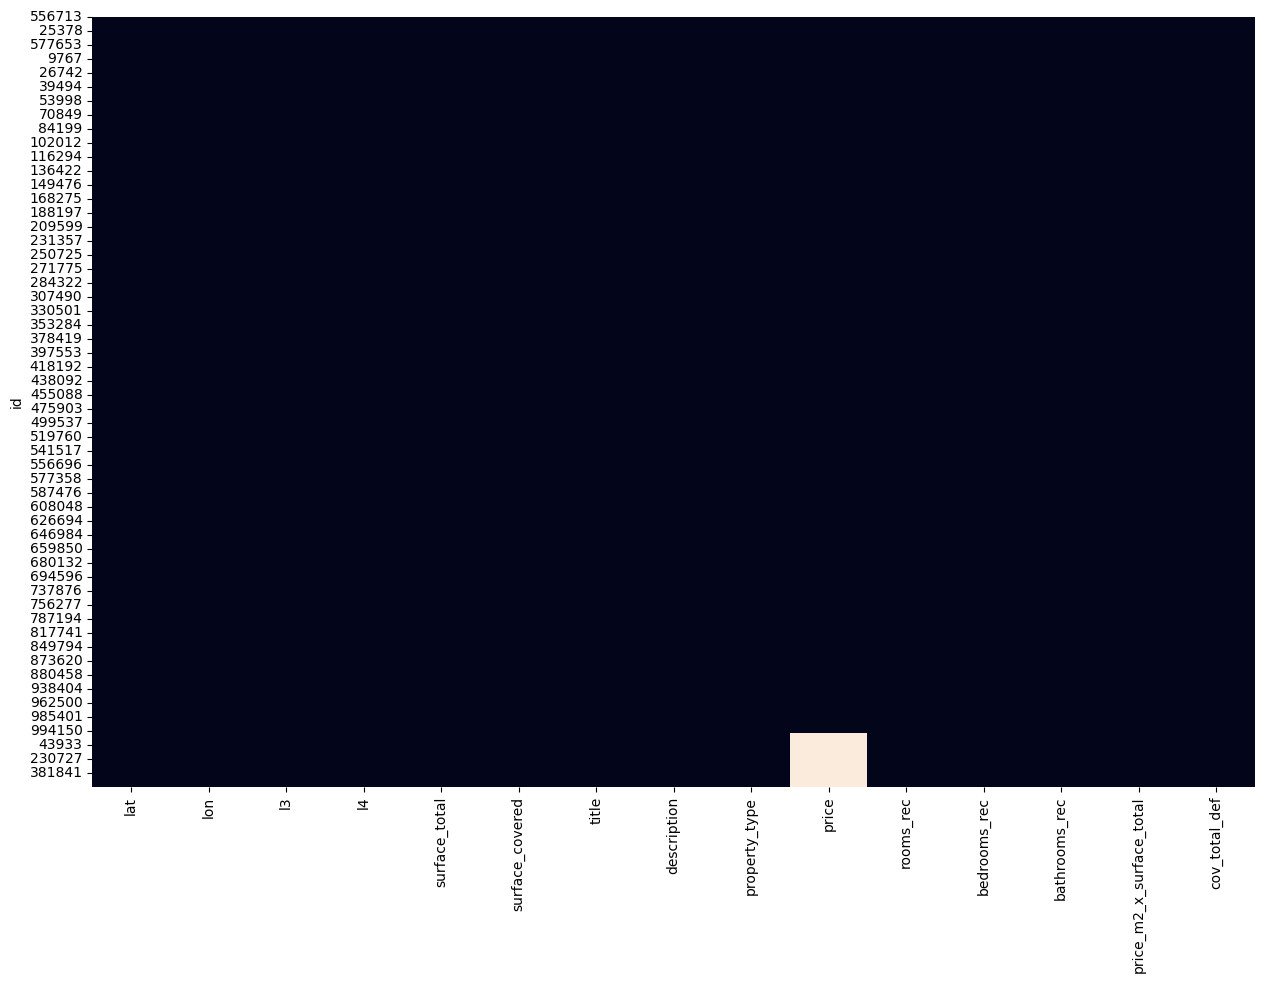

In [57]:
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(df.isnull(), cbar=False)

In [58]:
# # busco cualidades en titulo y descripción
# # roberto no

df['PH'] = (
    df['title'].astype(str).str.lower().str.contains('ph', na=False) |
    df['description'].astype(str).str.lower().str.contains('ph', na=False)
).astype(int)

df['tiene_pileta'] = (
    df['title'].astype(str).str.lower().str.contains('pileta|piscina|natatorio', na=False) |
    df['description'].astype(str).str.lower().str.contains('pileta|piscina|natatorio', na=False)
).astype(int)



df['a_estrenar'] = (
    df['title'].astype(str).str.lower().str.contains('a estrenar|para estrenar|sin estrenar', na=False) |
    df['description'].astype(str).str.lower().str.contains('a estrenar|para estrenar|sin estrenar', na=False)
).astype(int)

df['de_pozo'] = (
    df['title'].astype(str).str.lower().str.contains('de pozo|pozo', na=False) |
    df['description'].astype(str).str.lower().str.contains('de pozo|pozo', na=False)
).astype(int)



In [59]:
print("Cantidad de propiedades PH:", df['PH'].sum())
print("Cantidad de propiedades con pileta:", df['tiene_pileta'].sum())
print("Cantidad de propiedades a estrenar:", df['a_estrenar'].sum())
print("Cantidad de propiedades de pozo:", df['de_pozo'].sum())

Cantidad de propiedades PH: 10791
Cantidad de propiedades con pileta: 19782
Cantidad de propiedades a estrenar: 8937
Cantidad de propiedades de pozo: 2043


In [60]:
df.columns

Index(['lat', 'lon', 'l3', 'l4', 'surface_total', 'surface_covered', 'title',
       'description', 'property_type', 'price', 'rooms_rec', 'bedrooms_rec',
       'bathrooms_rec', 'price_m2_x_surface_total', 'cov_total_def', 'PH',
       'tiene_pileta', 'a_estrenar', 'de_pozo'],
      dtype='object')

In [61]:
f=df["l4"]=="Palermo Chico"
df.loc[f,"Palermo_Chico"]=1

In [62]:
df["Palermo_Chico"].fillna(0,inplace=True)

C:\Users\chris\AppData\Local\Temp\ipykernel_28720\903351936.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Palermo_Chico"].fillna(0,inplace=True)


In [63]:
f=df["l4"]=="Palermo"
df.loc[f,"Palermo"]=1
df["Palermo"].fillna(0,inplace=True)

C:\Users\chris\AppData\Local\Temp\ipykernel_28720\1633183090.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Palermo"].fillna(0,inplace=True)


## 3. Entrenamiento del modelos (AA)

In [64]:
f_ent = df["price"].notna()
df_ent=df.loc[f_ent].copy()
df_ent.shape

(93313, 21)

In [65]:

df_ent = df_ent.select_dtypes(['number', 'bool'])
print(df_ent.columns)
X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

Index(['lat', 'lon', 'surface_total', 'surface_covered', 'price', 'rooms_rec',
       'bedrooms_rec', 'bathrooms_rec', 'price_m2_x_surface_total',
       'cov_total_def', 'PH', 'tiene_pileta', 'a_estrenar', 'de_pozo',
       'Palermo_Chico', 'Palermo'],
      dtype='object')


In [67]:
### Versión con train/test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

best_score_test = 1000000

### Usar sólo RandomForestRegressor o GradientBoostingRegressor, no otros
### Pueden cambiar los hiperparámetros


n_estimators=500
max_depth=30

reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=4, random_state=42)

# Entrenamos el modelo
_ = reg.fit(X_train, y_train)

# Cálculo del error en entrenamiento (train)
y_pred = reg.predict(X_train)
score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)

# Cálculo del error en prueba (test)
y_pred = reg.predict(X_test)
score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)

best_score_test = min(best_score_test, score_test)

print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")

n_estimators=500 -- max_depth=30 --> score_train=26451.69 - score_test=84084.20 - best_score_test=84084.20


In [1188]:
### Versión con train/test split
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

best_score_test = 1000000
for n_estimators in [10, 50, 100, 300, 500, 700, 1000]:
    for max_depth in [5, 10, 20, 30, 50, None]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=4, random_state=42)
        _ = reg.fit(X_train, y_train)
        y_pred = reg.predict(X_train)
        score_train = sk.metrics.root_mean_squared_error(y_train, y_pred)
        y_pred = reg.predict(X_test)
        score_test  = sk.metrics.root_mean_squared_error(y_test,  y_pred)
        best_score_test = min(best_score_test, score_test)
        print(f"{n_estimators=} -- {max_depth=} --> {score_train=:.2f} - {score_test=:.2f} - {best_score_test=:.2f}")

n_estimators=10 -- max_depth=5 --> score_train=64923.79 - score_test=67225.73 - best_score_test=67225.73
n_estimators=10 -- max_depth=10 --> score_train=47234.01 - score_test=54624.51 - best_score_test=54624.51
n_estimators=10 -- max_depth=20 --> score_train=24258.29 - score_test=48644.15 - best_score_test=48644.15
n_estimators=10 -- max_depth=30 --> score_train=21922.74 - score_test=48585.46 - best_score_test=48585.46
n_estimators=10 -- max_depth=50 --> score_train=22208.75 - score_test=48407.99 - best_score_test=48407.99
n_estimators=10 -- max_depth=None --> score_train=22208.75 - score_test=48407.99 - best_score_test=48407.99
n_estimators=50 -- max_depth=5 --> score_train=64364.66 - score_test=66526.08 - best_score_test=48407.99
n_estimators=50 -- max_depth=10 --> score_train=46279.82 - score_test=54179.40 - best_score_test=48407.99
n_estimators=50 -- max_depth=20 --> score_train=21727.00 - score_test=47348.05 - best_score_test=47348.05
n_estimators=50 -- max_depth=30 --> score_trai

KeyboardInterrupt: 

In [68]:
### Versión con validación cruzada

best_score = 1000000

### Usar sólo RandomForestRegressor o GradientBoostingRegressor, no otros
### Pueden cambiar los hiperparámetros
for n_estimators in [10, 50, 100, 300, 500, 700, 1000]:

    # for max_depth in [3, 5, 8, 10, 12]:
    # 	reg = sk.ensemble.GradientBoostingRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)

    for max_depth in [5, 10, 20, 30, 50, None]:
        reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=4, random_state=42)

        # Entrenamos el modelo (cross validation en 5 partes)
        scores = -1*sk.model_selection.cross_val_score(reg, X, y, cv=5, scoring="neg_root_mean_squared_error", n_jobs=4)

        scores_mean = scores.mean()
        scores_std = scores.std()

        best_score = min(best_score, scores_mean)

        print(f"{n_estimators=} -- {max_depth=} --> {scores_mean=:.2f} - {scores_std=:.2f} - {best_score=:.2f}")

n_estimators=10 -- max_depth=5 --> scores_mean=115697.09 - scores_std=10314.35 - best_score=115697.09
n_estimators=10 -- max_depth=10 --> scores_mean=81166.72 - scores_std=5310.78 - best_score=81166.72
n_estimators=10 -- max_depth=20 --> scores_mean=74745.54 - scores_std=5030.14 - best_score=74745.54
n_estimators=10 -- max_depth=30 --> scores_mean=74772.36 - scores_std=5085.96 - best_score=74745.54
n_estimators=10 -- max_depth=50 --> scores_mean=75398.46 - scores_std=4746.02 - best_score=74745.54
n_estimators=10 -- max_depth=None --> scores_mean=75398.53 - scores_std=4745.91 - best_score=74745.54
n_estimators=50 -- max_depth=5 --> scores_mean=114753.80 - scores_std=9608.31 - best_score=74745.54
n_estimators=50 -- max_depth=10 --> scores_mean=80619.40 - scores_std=4797.65 - best_score=74745.54
n_estimators=50 -- max_depth=20 --> scores_mean=72431.14 - scores_std=4077.75 - best_score=72431.14
n_estimators=50 -- max_depth=30 --> scores_mean=72285.91 - scores_std=4212.00 - best_score=72285

KeyboardInterrupt: 

In [75]:
X = df_ent[df_ent.columns.drop('price')]
y = df_ent['price']

# Entrenamos el modelo con todos los datos de entrenamiento.csv, con los mejores hiperparámetros
n_estimators = 500
max_depth = 30
reg = sk.ensemble.RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, n_jobs=4, random_state=42)

reg.fit(X, y)


RandomForestRegressor(max_depth=30, n_estimators=500, n_jobs=4, random_state=42)

In [71]:
f_ap=df["price"].isna()
df_ap=df.loc[f_ap].copy()
df_ap.shape

(7012, 21)

In [74]:
# Hacemos en df_ap la misma limpieza que en df_ent
# df_ap = df_ap.fillna(0)

df_ap = df_ap.select_dtypes(['number', 'bool'])

X_ap = df_ap[X.columns]
y_ap = df_ap['price'] # no es necesario!

# Predecimos los precios del dataset a predecir
y_pred_ap = reg.predict(X_ap)
y_pred_ap

array([476749.91160017, 790000.        , 215189.29333333, ...,
       825000.        , 200592.17234815, 249003.77777778], shape=(7012,))

## 4. Solución para subir Kaggle

In [73]:
# Lleno el precio de df_ap con las predicciones
df_ap["price"] = y_pred_ap

# Grabo el df_ap en un archivo csv para subir a Kaggle
df_ap["price"].to_csv("solucion_v_hp.csv")

In [235]:
# Importancia de las columnas
pd.DataFrame({"importance": reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)

,importance
price_m2_x_surface_total,0.709817
surface_covered,0.050747
lon,0.049938
lat,0.038899
cov_total_def,0.036805
surface_total,0.031896
Palermo_Chico,0.018420
bathrooms_rec,0.013821
tiene_pileta,0.013288
bedrooms_rec,0.011510


<Axes: xlabel='importance', ylabel='None'>

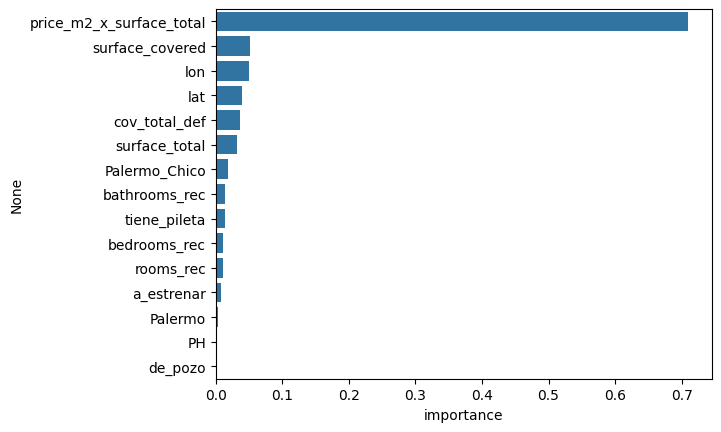

In [236]:
# Importancia de las columnas
importances = pd.DataFrame({"importance": reg.feature_importances_}, index=X.columns).sort_values(by="importance", ascending=False)
importances
sns.barplot(data=importances,x="importance",y=importances.index)